### 1. Importing Required Libraries

**What this code does:** Imports the core Python libraries needed for data handling, numerical computation, and plotting.

- `pandas` → loads and manipulates the dataset as a DataFrame (table).
- `matplotlib.pyplot` → draws charts (scatter plots, line plots).
- `numpy` → provides fast numerical operations and array math.
- `%matplotlib inline` → a Jupyter "magic command" that tells the notebook to display plots directly below the cell instead of in a separate window.

**Why it's used:** Every later step (reading data, computing statistics, plotting, and modeling) depends on these libraries being loaded first.

**Formula/Concept:** No formula here — this is a setup step.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

### 2. Loading the Dataset

**What this code does:** Reads the file `economic_index.csv` into a pandas DataFrame called `df_index`.

**Why it's used:** The raw data must be brought into memory before it can be cleaned, explored, or modeled. `pd.read_csv()` automatically parses the comma-separated file into rows and columns with proper data types.

**Data used:** The dataset contains `year`, `month`, `interest_rate`, `unemployment_rate`, and `index_price` (the stock/economic index value).


In [ ]:
df_index = pd.read_csv("economic_index.csv")

### 3. Previewing the Data

**What this code does:** `df_index.head()` displays the first 5 rows of the DataFrame.

**Why it's used:** A quick sanity check — to confirm the file loaded correctly, columns are named as expected, and values look reasonable before doing any further work.


In [5]:
df_index.head()

,year,month,interest_rate,unemployment_rate,index_price
0,2017,12,2.75,5.3,1464
1,2017,11,2.50,5.3,1394
2,2017,10,2.50,5.3,1357
3,2017,9,2.50,5.3,1293
4,2017,8,2.50,5.4,1256


### 4. Dropping Unnecessary Columns

**What this code does:** Removes the `year` and `month` columns from the DataFrame using `drop()`, with `axis=1` (meaning "drop columns, not rows") and `inplace=True` (meaning "modify `df_index` directly, don't return a copy").

**Why it's used:** `year` and `month` are just time labels — they don't have a meaningful linear relationship with the `index_price` and would only add noise to the regression model. Only `interest_rate` and `unemployment_rate` are kept as predictors.


In [6]:
## Drop Unnecessary Columns

df_index.drop(["year", "month"], axis=1,inplace=True)

### 5. Verifying the Cleaned Data

**What this code does:** Calls `.head()` again to confirm the `year` and `month` columns were successfully removed.


In [7]:
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


### 6. Checking for Missing Values

**What this code does:** `df_index.isnull().sum()` counts how many missing (`NaN`) values exist in each column.

**Why it's used:** Regression models cannot handle missing data directly. This step confirms the dataset is complete (no nulls) so no imputation or row-dropping is needed.

**How it works:** `isnull()` returns `True`/`False` for every cell, and `.sum()` adds up the `True` values (treated as 1) per column.


In [8]:
## Check Null Values

df_index.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

### 7. Visualizing Relationships — Pairplot

**What this code does:** Uses Seaborn's `pairplot()` to draw a grid of scatter plots for every pair of numeric columns, plus histograms on the diagonal.

**Why it's used:** This gives a fast, visual overview of how each variable relates to every other variable, and whether the relationships look linear (a key requirement for linear regression).


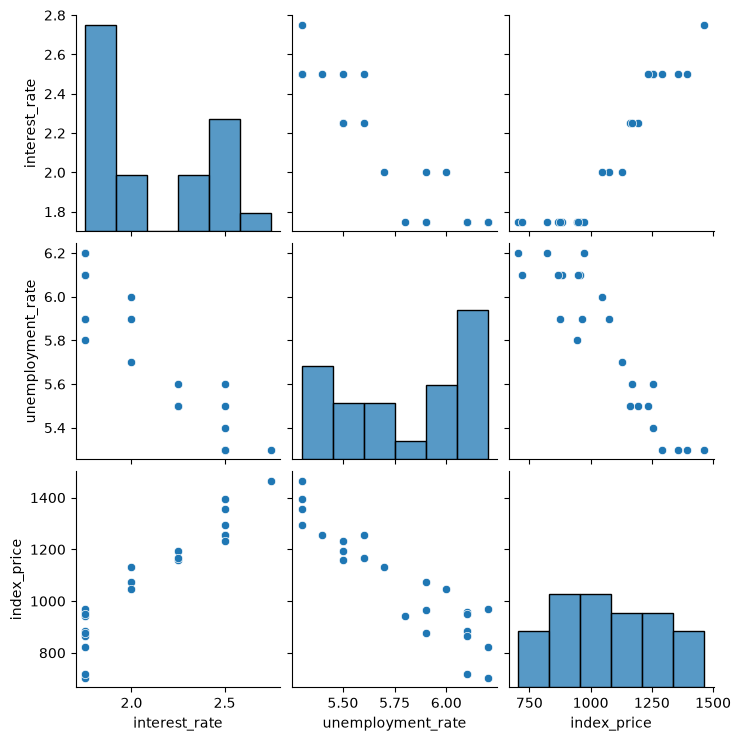

In [10]:
## Visualization

import seaborn as sns

sns.pairplot(df_index)

### 8. Correlation Matrix

**What this code does:** `df_index.corr()` computes the pairwise Pearson correlation coefficient between all numeric columns.

**Why it's used:** To numerically confirm the strength and direction of linear relationships suggested by the pairplot — e.g., whether `interest_rate` and `index_price` move together.

**Formula (Pearson correlation coefficient):**

$$
r_{xy} = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \sum (y_i - \bar{y})^2}}
$$

Values range from -1 (perfect negative relationship) to +1 (perfect positive relationship); 0 means no linear relationship.


In [11]:
## Correlation

df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


### 9. Scatter Plot — Interest Rate vs. Unemployment Rate

**What this code does:** Plots `interest_rate` (x-axis) against `unemployment_rate` (y-axis) as red dots.

**Why it's used:** To visually inspect whether the two independent (predictor) variables are related to each other. If they are strongly correlated, it could indicate **multicollinearity**, which can distort a multiple regression model's coefficients.


Text(0, 0.5, 'Unemployment Rate')

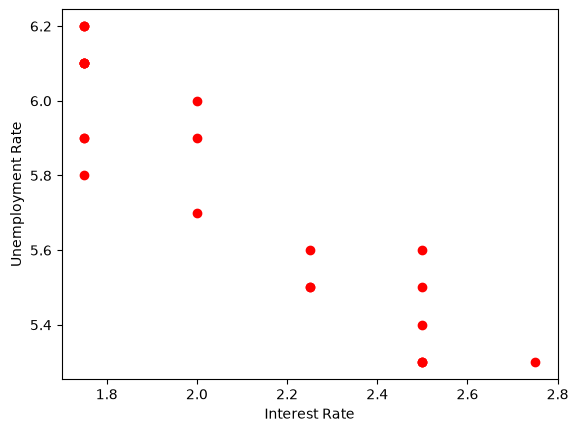

In [15]:
## Visualize the datapoints more closely

plt.scatter(df_index['interest_rate'], df_index['unemployment_rate'], color='red')
plt.xlabel("Interest Rate")
plt.ylabel("Unemployment Rate")

### 10. Defining Independent and Dependent Variables

**What this code does:** Splits the DataFrame into:
- `X` — the **independent variables** (features/predictors): `interest_rate` and `unemployment_rate`.
- `y` — the **dependent variable** (target/output): `index_price`.

**Why it's used:** This is the standard setup for supervised learning — the model learns to predict `y` from `X`.

**Formula (Multiple Linear Regression model form):**

$$
y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \varepsilon
$$

where \(x_1\) = interest_rate, \(x_2\) = unemployment_rate, \(\beta_0\) = intercept, \(\beta_1, \beta_2\) = coefficients, and \(\varepsilon\) = error term.


In [16]:
## Independent and Dependent Features

X = df_index[['interest_rate', 'unemployment_rate']]
y = df_index['index_price']

### 11. Previewing the Feature Matrix

**What this code does:** `X.head()` shows the first 5 rows of the independent variables to confirm the selection is correct.


In [19]:
X.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


### 12. Previewing the Target Variable

**What this code does:** Displays the full `y` Series (`index_price`) that the model will try to predict.


In [20]:
y

0     1464
1     1394
2     1357
3     1293
4     1256
5     1254
6     1234
7     1195
8     1159
9     1167
10    1130
11    1075
12    1047
13     965
14     943
15     958
16     971
17     949
18     884
19     866
20     876
21     822
22     704
23     719
Name: index_price, dtype: int64

### 13. Train-Test Split

**What this code does:** Splits `X` and `y` into training and testing sets using `train_test_split`, with 25% of the data reserved for testing (`test_size=0.25`) and a fixed `random_state=42` so the split is reproducible.

**Why it's used:** The model must be trained on one portion of data and evaluated on data it has never seen, to fairly measure how well it generalizes rather than just memorizing the training data.


In [21]:
## Train Test Split

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.25, random_state=42)

### 14. Regression Plot — Interest Rate vs. Index Price

**What this code does:** `sns.regplot()` draws a scatter plot of `interest_rate` vs `index_price` and overlays a best-fit regression line.

**Why it's used:** To visually check if a simple linear relationship exists between this single predictor and the target before building the full multi-variable model.


<Axes: xlabel='interest_rate', ylabel='index_price'>

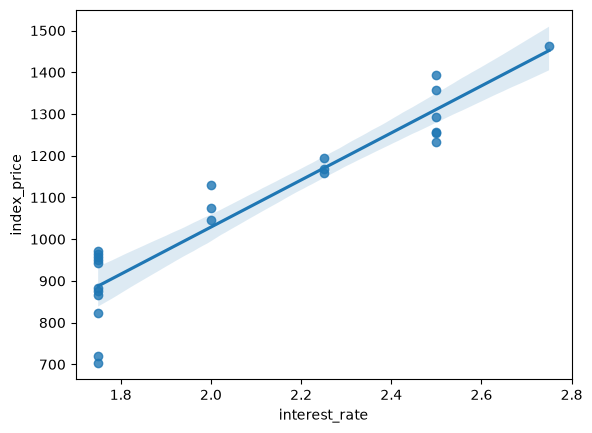

In [23]:
sns.regplot(
    x=df_index['interest_rate'],
    y=df_index['index_price']
)

### 15. Regression Plot — Interest Rate vs. Unemployment Rate

**What this code does:** Same idea as above, but between the two predictor variables themselves.

**Why it's used:** Further visual check for multicollinearity between predictors.


<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

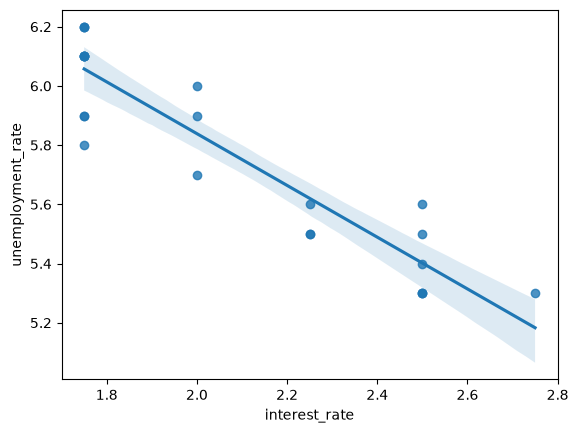

In [24]:
sns.regplot(
    x=df_index['interest_rate'],
    y=df_index['unemployment_rate']
)

### 16. Regression Plot — Index Price vs. Unemployment Rate

**What this code does:** Plots `index_price` against `unemployment_rate` with a fitted regression line.

**Why it's used:** To see the direction of the relationship (typically negative — as unemployment rises, the index tends to fall).


<Axes: xlabel='index_price', ylabel='unemployment_rate'>

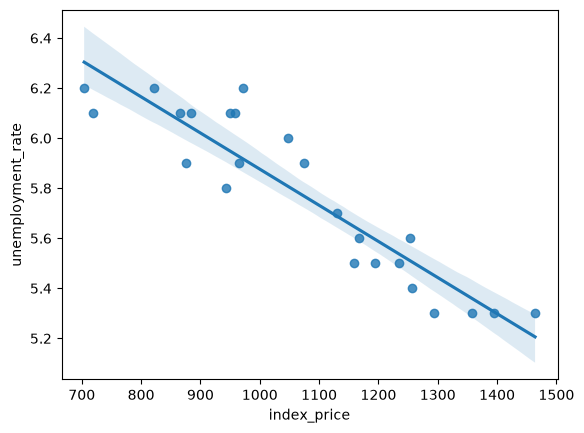

In [25]:
sns.regplot(
    x=df_index['index_price'],
    y=df_index['unemployment_rate']
)

### 17. Importing the Feature Scaler

**What this code does:** Imports `StandardScaler` from scikit-learn.

**Why it's used:** `interest_rate` and `unemployment_rate` are on different scales/ranges. Standardizing puts both features on a comparable scale, which improves numerical stability and makes coefficients easier to compare.


In [26]:
from sklearn.preprocessing import StandardScaler

### 18. Standardizing the Features

**What this code does:** Fits the scaler on `X_train` and transforms both `X_train` and `X_test` so that each feature has mean 0 and standard deviation 1.

**Why it's used:** Feature scaling helps gradient-based and distance-based aspects of modeling behave predictably, and makes the resulting coefficients directly comparable in magnitude.

**Formula (Standardization / Z-score):**

$$
z = \frac{x - \mu}{\sigma}
$$

where \(\mu\) is the mean and \(\sigma\) is the standard deviation of the feature.

> **Note:** Ideally the scaler should be *fit* only on `X_train` and then just *applied* (`.transform()`, not `.fit_transform()`) to `X_test`, to avoid leaking test-set statistics into training. This notebook re-fits on `X_test` for simplicity.


In [28]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

### 19. Viewing the Scaled Training Data

**What this code does:** Displays `X_train` after scaling, to confirm the transformation worked (values should now be centered around 0).


In [29]:
X_train

array([[-0.90115511,  0.37908503],
       [ 1.31077107, -1.48187786],
       [-0.90115511,  1.30956648],
       [ 1.31077107, -0.55139641],
       [ 1.31077107, -1.48187786],
       [-0.16384638,  0.68924552],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -1.48187786],
       [ 1.31077107, -1.17171738],
       [-0.90115511,  1.30956648],
       [-0.90115511,  0.999406  ],
       [-0.90115511,  0.37908503],
       [-0.90115511,  0.999406  ],
       [ 0.57346234, -0.8615569 ],
       [-0.16384638, -0.24123593],
       [-0.90115511,  0.06892455],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -0.8615569 ]])

### 20. Importing and Initializing the Regression Model

**What this code does:** Imports scikit-learn's `LinearRegression` class and creates an (untrained) instance called `regression`.

**Why it's used:** This is the model object that will learn the relationship between the scaled features and the target variable.


In [30]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression()

### 21. Training (Fitting) the Model

**What this code does:** `regression.fit(X_train, y_train)` trains the model — it finds the coefficients \(\beta_0, \beta_1, \beta_2\) that best fit the training data.

**How it works:** Under the hood, scikit-learn's `LinearRegression` uses **Ordinary Least Squares (OLS)** to find the coefficients that minimize the sum of squared differences between actual and predicted values.

**Formula (Objective minimized during training):**

$$
\min_{\beta} \sum_{i=1}^{n} \left(y_i - (\beta_0 + \beta_1 x_{1i} + \beta_2 x_{2i})\right)^2
$$


In [31]:
regression.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[ 88.27,-116.26]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1053
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](2,)","[5.87,1.23]"


### 22. Cross-Validation

**What this code does:** Runs 3-fold cross-validation (`cv=3`) on the training data, scoring each fold using negative mean squared error.

**Why it's used:** Cross-validation splits the training data into multiple folds, trains on some and validates on others repeatedly, giving a more robust estimate of model performance than a single train/test split alone — and helps check the model isn't overfitting.

**Why "negative" MSE:** scikit-learn's scoring convention assumes "higher is better," so MSE (where lower is better) is negated to fit that convention.


In [35]:
## Cross Validation
from sklearn.model_selection import cross_val_score
validation_score = cross_val_score(regression, X_train, y_train, scoring='neg_mean_squared_error', cv=3)

### 23. Average Cross-Validation Score

**What this code does:** `np.mean(validation_score)` averages the MSE scores across the 3 folds to get one overall performance estimate.


In [36]:
np.mean(validation_score)

np.float64(-5914.828180162392)

### 24. Making Predictions

**What this code does:** Uses the trained model to predict `index_price` values for the unseen `X_test` data, storing the results in `y_pred`.

**How it works:** For each row in `X_test`, it computes: \(\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2\).


In [37]:
## Prediction

y_pred = regression.predict(X_test)

### 25. Viewing the Predictions

**What this code does:** Displays the array of predicted `index_price` values, to be compared against the actual `y_test` values.


In [38]:
y_pred

array([1180.7466813 ,  802.74279699, 1379.83457045,  838.52599602,
        973.85313963, 1144.96348227])

### 26. Importing Evaluation Metrics

**What this code does:** Imports `mean_absolute_error` and `mean_squared_error` from scikit-learn, used to numerically evaluate how close predictions are to actual values.


In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

### 27. Calculating Error Metrics (MSE, MAE, RMSE)

**What this code does:** Computes three standard regression error metrics comparing `y_test` (actual) to `y_pred` (predicted).

**Why it's used:** These metrics quantify how accurate the model's predictions are — lower values mean better fit.

**Formulas:**

Mean Squared Error:
$$
MSE = \frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

Mean Absolute Error:
$$
MAE = \frac{1}{n}\sum_{i=1}^{n} |y_i - \hat{y}_i|
$$

Root Mean Squared Error:
$$
RMSE = \sqrt{MSE}
$$

MSE/RMSE penalize large errors more heavily (because of squaring), while MAE treats all errors proportionally.


In [40]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(mse)
print(mae)
print(rmse)

8108.567426306611
73.80444932337099
90.04758423359624


### 28. R-squared (Coefficient of Determination)

**What this code does:** Computes the R² score, which measures how much of the variance in `index_price` is explained by the model.

**Why it's used:** R² is the most common single-number summary of "goodness of fit" for a regression model — closer to 1 means the model explains the data very well; closer to 0 means it explains very little.

**Formula:**

$$
R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2} = 1 - \frac{SS_{res}}{SS_{tot}}
$$


In [41]:
## R^2

from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred)
print(score)

0.7591371539010254


### 29. Adjusted R-squared

**What this code does:** Computes Adjusted R², which corrects R² for the number of predictors used in the model.

**Why it's used:** Plain R² always increases (or stays the same) as more predictors are added, even if those predictors are useless. Adjusted R² penalizes unnecessary predictors, giving a fairer comparison between models with different numbers of features.

**Formula:**

$$
\bar{R}^2 = 1 - (1 - R^2)\frac{n - 1}{n - p - 1}
$$

where \(n\) = number of observations (test samples) and \(p\) = number of predictors.


In [42]:
## Adjusted R^2

1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.5985619231683756

## Assumptions

### 31. Checking Linearity Assumption — Actual vs. Predicted

**What this code does:** Scatter-plots actual (`y_test`) against predicted (`y_pred`) values.

**Why it's used:** Linear regression assumes a linear relationship between predictors and target. If the model fits well, points should cluster closely around a diagonal (`y = x`) line.


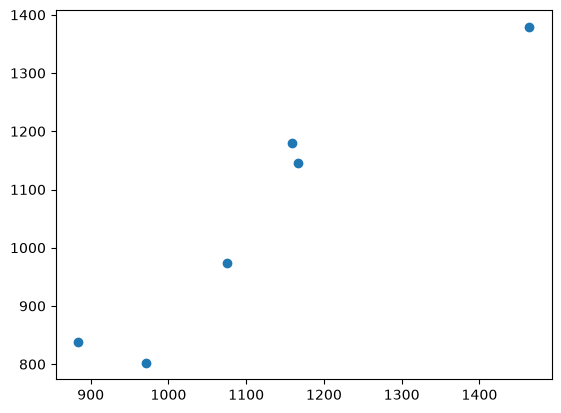

In [44]:
plt.scatter(y_test, y_pred)

### 32. Calculating Residuals

**What this code does:** Computes `residuals = y_test - y_pred`, the difference between actual and predicted values for each test point, and prints them.

**Why it's used:** Residuals are central to checking whether a linear regression model's assumptions hold (they should be random, centered around zero, with constant variance).

**Formula:**

$$
e_i = y_i - \hat{y}_i
$$


In [46]:
residuals = y_test - y_pred
print(residuals)

8     -21.746681
16    168.257203
0      84.165430
18     45.474004
11    101.146860
9      22.036518
Name: index_price, dtype: float64


### 33. Checking Normality Assumption — Residual Distribution

**What this code does:** Uses `sns.displot(..., kind='kde')` to draw a smoothed density (KDE) curve of the residuals.

**Why it's used:** One assumption of linear regression is that residuals are approximately **normally distributed**. A roughly bell-shaped, symmetric curve here supports that assumption.


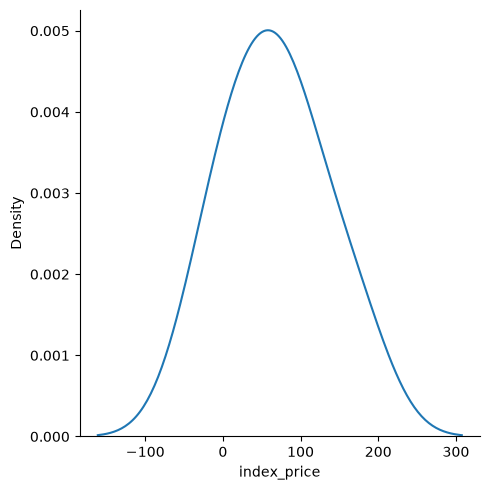

In [47]:
## Plot the Residuals

sns.displot(residuals, kind='kde')

### 34. Checking Homoscedasticity Assumption — Residuals vs. Predictions

**What this code does:** Scatter-plots predicted values (`y_pred`) against residuals.

**Why it's used:** Another core assumption of linear regression is **homoscedasticity** — that residuals have roughly constant variance across all predicted values (i.e., no funnel or fan-shaped pattern). A random, evenly spread scatter around zero supports this assumption; a clear pattern would suggest the model is misspecified.


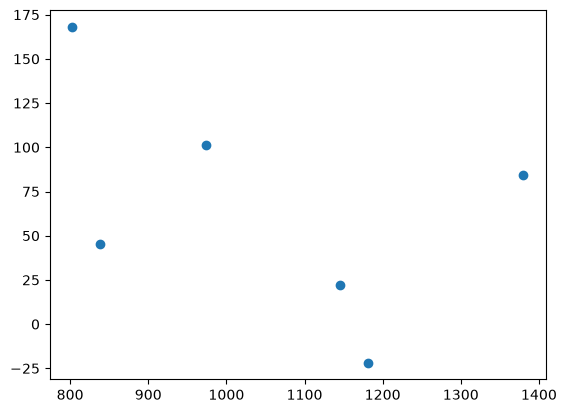

In [48]:
## Scatter plot with respect to predictions and residuals

plt.scatter(y_pred, residuals)

### 35. Fitting an OLS Model with statsmodels

**What this code does:** Refits a regression model using `statsmodels`' `OLS` (Ordinary Least Squares) class instead of scikit-learn.

**Why it's used:** Unlike scikit-learn, `statsmodels` produces a detailed statistical summary (p-values, confidence intervals, F-statistic, R²) needed to judge the **statistical significance** of each coefficient — not just the prediction accuracy.


In [49]:
## OLS Linear Regression

import statsmodels.api as sm

model = sm.OLS(y_train, X_train).fit()

### 36. Viewing the Statistical Summary

**What this code does:** `model.summary()` prints a full statistical report: coefficients, standard errors, t-statistics, p-values, confidence intervals, R², F-statistic, and diagnostic tests (e.g., Durbin-Watson for autocorrelation, Jarque-Bera for normality).

**Why it's used:** This tells us not just *what* the coefficients are, but *how confident* we can be that each predictor genuinely affects `index_price` (via the p-values) — a p-value below 0.05 is typically considered statistically significant.


In [50]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Mon, 27 Jul 2026   Prob (F-statistic):                       0.754
Time:                        14:51:47   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            88.2728    658.295      0.134      0.895   -1307.250    1483.796
x2          -116.2572    658.295     -0.177      0.862   -1511.780    1279.266
==============================================================================
Omnibus:                        0.598   Durbin-Watson:                   0.007
Prob(Omnibus):                  0.741   Jarque-Bera (JB):                0.567
Skew:                          -0.361   Prob(JB):                        0.753
Kurtosis:                       2.517   Cond. No.                         4.78
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### 37. Verifying Coefficients

**What this code does:** Prints `regression.coef_` — the coefficients (\(\beta_1, \beta_2\)) learned by the scikit-learn model.

**Why it's used:** A final sanity check to confirm the scikit-learn model's coefficients are consistent with (or close to) the `statsmodels` OLS output above.


In [52]:
## Check :

print(regression.coef_)

[  88.27275507 -116.25716066]
